# Soft Actor-Critic (SAC)

# SAC on CarRacing-v3

This notebook implements and evaluates Soft Actor-Critic (SAC) on the CarRacing-v3 environment from Gymnasium.

The objective is to study how SAC behaves in a challenging vision-based continuous control task involving:
- high-dimensional image observations,
- continuous actions,
- delayed rewards,
- and procedurally generated tracks.

In addition to final performance, we analyze:
- sample efficiency,
- training stability,
- entropy behavior,
- and value/actor optimization dynamics.

In [ ]:
!pip install swig

In [ ]:
!pip install stable_baselines3 gymnasium[box2d]

## Environment Setup
We use:
- Gymnasium for the environment interface
- Stable-Baselines3 for SAC implementation
- PyTorch for GPU acceleration
- Training is executed on Google Colab with optional CUDA support.


In [ ]:
import gymnasium
from gymnasium.wrappers import RecordVideo
from stable_baselines3 import SAC
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.atari_wrappers import WarpFrame
from stable_baselines3.common.vec_env import VecFrameStack, VecVideoRecorder
from stable_baselines3.common.callbacks import BaseCallback, EvalCallback
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.vec_env import VecTransposeImage
from stable_baselines3.common.callbacks import CallbackList, CheckpointCallback

import os
import torch
import numpy as np
import platform
import stable_baselines3
import matplotlib
import matplotlib.pyplot as plt
from platform import python_version
from importlib.metadata import version

## System Configuration
This section prints system versions to ensure reproducibility across experiments.


In [ ]:
print(f"Python Version: {platform.python_version()}")
print(f"Torch Version: {version('torch')}")
print(f"Is Cuda Available: {torch.cuda.is_available()}")
print(f"Cuda Version: {torch.version.cuda}")
if torch.cuda.is_available(): print(f"GPU Device: {torch.cuda.get_device_name(0)}")
print(f"Gymnasium Version: {version('gymnasium')}")
print(f"Numpy Version: {version('numpy')}")
print(f"Scipy Version: {version('scipy')}")
print(f"Swig Version: {version('swig')}")
print(f"Stable Baselines3 Version: {version('stable_baselines3')}")
print(f"IPython Version: {version('ipython')}")

Python Version: 3.12.13
Torch Version: 2.10.0+cu128
Is Cuda Available: True
Cuda Version: 12.8
GPU Device: Tesla T4
Gymnasium Version: 1.2.3
Numpy Version: 2.0.2
Scipy Version: 1.16.3
Swig Version: 4.4.1
Stable Baselines3 Version: 2.8.0
IPython Version: 7.34.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Experiment Configuration

We define the main training configuration:
- SAC as the reinforcement learning algorithm,
- CarRacing-v3 as the environment,
- grayscale preprocessing,
- frame stacking,
- periodic evaluation checkpoints,
- and persistent logging to Google Drive.

In [ ]:
# ==============================
# Config
# ==============================
rl_type = "SAC"
env_str = "CarRacing-v3"
log_dir = f"/content/drive/MyDrive/sac_car_racing_latest/{env_str}/{rl_type}"
os.makedirs(log_dir, exist_ok=True)

name_prefix = "car_racing"
gray_scale = True
# If gray_scale True, convert obs to gray scale 84 x 84 image
wrapper_class = WarpFrame if gray_scale else None
TOTAL_TIMESTEPS = 500_000 # additional steps when resuming
EVAL_FREQ = 25_000



In [ ]:
env = gymnasium.make('CarRacing-v3')
print("Observation Space Size: ", env.observation_space.shape)
print("Action Space Size: ", env.action_space.shape)
env.close()

Observation Space Size:  (96, 96, 3)
Action Space Size:  (3,)


## Observation Preprocessing

Raw RGB observations are computationally expensive and contain redundant information.

To improve training efficiency and numerical stability:
1. observations are converted to grayscale,
2. resized to 84×84,
3. stacked across 4 consecutive frames,
4. and transposed into channel-first format for PyTorch.

Frame stacking is particularly important because a single image does not encode velocity information.

In [ ]:
# ==============================
# Create environments
# ==============================
env = make_vec_env(env_str,
                   n_envs=1,
                   wrapper_class=wrapper_class,
                   monitor_dir=os.path.join(log_dir, "monitor"))
env = VecFrameStack(env, n_stack=4)
env = VecTransposeImage(env)

env_val = make_vec_env(env_str, n_envs=1, wrapper_class=wrapper_class)
env_val = VecFrameStack(env_val, n_stack=4)
env_val = VecTransposeImage(env_val)

## Evaluation and Checkpointing

To monitor learning progression, the agent is evaluated every 25,000 timesteps over 20 deterministic episodes.

We also save:
- periodic checkpoints,
- tensorboard logs,
- and the best-performing model.

This allows recovery from interruptions and enables detailed post-training analysis.

In [ ]:
# ==============================
# Callbacks
# ==============================
eval_callback = EvalCallback( env_val,
                             best_model_save_path=log_dir,
                              log_path=log_dir,
                              eval_freq=EVAL_FREQ,
                              render=False,
                              deterministic=True,
                              n_eval_episodes=20 )

checkpoint_callback = CheckpointCallback( save_freq=EVAL_FREQ,
                                         save_path=os.path.join(log_dir, "checkpoint"),
                                          name_prefix="rl_model" )

callbackList = CallbackList([checkpoint_callback, eval_callback])

## SAC Model
We use Stable-Baselines3's CnnPolicy, which combines:
- convolutional feature extraction,
- a stochastic Gaussian policy,
- twin Q-function critics,
- and entropy maximization.

The entropy coefficient is set to 0.0075 to encourage additional exploration during training.

In [ ]:
# ==============================
# Resume or create model
# ==============================
best_model_path = os.path.join(log_dir, "best_model.zip")
checkpoint_dir = os.path.join(log_dir, "checkpoint")

def get_latest_checkpoint(path):
  if not os.path.exists(path):
    return None
  files = [f for f in os.listdir(path) if f.endswith(".zip")]
  if not files:
    return None
  files.sort(key=lambda x: int(x.split("_")[-2]))
  return os.path.join(path, files[-1])

latest_checkpoint = get_latest_checkpoint(checkpoint_dir)

if latest_checkpoint:
  print(f"Resuming from checkpoint: {latest_checkpoint}")
  model = SAC.load(latest_checkpoint, env=env)
elif os.path.exists(best_model_path):
  print("Loading best model...")
  model = SAC.load(best_model_path, env=env)
else:
  print("Creating new model...")
  model = SAC( "CnnPolicy",
               env,
               verbose=0,
               ent_coef=0.0075,
               tensorboard_log=os.path.join(log_dir, "tensorboard") )

Loading best model...


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/buffers.py:242: UserWarning: This system does not have apparently enough memory to store the complete replay buffer 56.47GB > 11.18GB
  warnings.warn(


## Training Procedure
The SAC agent is trained for 1 400,000 timesteps.
SAC uses off-policy learning with a replay buffer, which allows:
- higher sample efficiency,
- more stable learning updates,
- and multiple gradient updates per environment step.

This makes SAC particularly effective in continuous control tasks like CarRacing-v3, where exploration is difficult.

In [ ]:
# ==============================
# Train
# ==============================
model.learn( total_timesteps=TOTAL_TIMESTEPS,
            callback=eval_callback,
             reset_num_timesteps=False)

Eval num_timesteps=1375000, episode_reward=503.85 +/- 206.78
Episode length: 1000.00 +/- 0.00
New best mean reward!
Eval num_timesteps=1400000, episode_reward=420.73 +/- 266.73
Episode length: 1000.00 +/- 0.00


In [ ]:
# ==============================
# Save final model
# ==============================

model.save(os.path.join(log_dir, "final_model"))
mean_reward, std_reward = evaluate_policy(model, env, n_eval_episodes=20)
print(f"Final Model - Mean reward: {mean_reward:.2f} +/- {std_reward:.2f}")

Final Model - Mean reward: 457.62 +/- 230.83


## Model Evaluation
After training, both:
- the final model,
- and the best saved checkpoint

are evaluated over 20 deterministic episodes.
Deterministic evaluation removes exploration noise and produces more reliable performance comparisons.

In [ ]:
# ==============================
# Evaluate best model
# ==============================

best_model = SAC.load(best_model_path, env=env)
mean_reward, std_reward = evaluate_policy(best_model, env, n_eval_episodes=20)
print(f"Best Model - Mean reward: {mean_reward:.2f} +/- {std_reward:.2f}")

video_env = VecVideoRecorder( env,
                             log_dir,
                              video_length=5000,
                              record_video_trigger=lambda x: x == 0,
                              name_prefix=f"best_model_{name_prefix}" )
obs = video_env.reset()
for _ in range(5000):
  action, _ = best_model.predict(obs)
  obs, rewards, dones, info = video_env.step(action)
  if dones[0]:
    break
video_env.close()

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/buffers.py:242: UserWarning: This system does not have apparently enough memory to store the complete replay buffer 56.47GB > 11.15GB
  warnings.warn(


Best Model - Mean reward: 359.74 +/- 213.62
Moviepy - Building video /content/drive/MyDrive/sac_car_racing_latest/CarRacing-v3/SAC/best_model_car_racing-step-0-to-step-5000.mp4.
Moviepy - Writing video /content/drive/MyDrive/sac_car_racing_latest/CarRacing-v3/SAC/best_model_car_racing-step-0-to-step-5000.mp4



Moviepy - Done !
Moviepy - video ready /content/drive/MyDrive/sac_car_racing_latest/CarRacing-v3/SAC/best_model_car_racing-step-0-to-step-5000.mp4


## Learning Curve Visualization
The following plots summarize SAC training performance over time.
We visualize:
- mean episode return,
- standard deviation,
- and learning stability over timesteps.

In [ ]:
# ==============================
# Plot results
# ==============================
data_path = os.path.join(log_dir, "evaluations.npz")
if os.path.exists(data_path):
  data = np.load(data_path)
  timesteps = data['timesteps']
  results = data['results']
  mean_results = np.mean(results, axis=1)
  std_results = np.std(results, axis=1)
  plt.figure()
  plt.plot(timesteps, mean_results)
  plt.fill_between( timesteps,
                   mean_results - std_results,
                    mean_results + std_results,
                    alpha=0.3 )
  plt.xlabel('Timesteps')
  plt.ylabel('Mean Reward')
  plt.title(f"{rl_type} Performance on {env_str}")
  plt.savefig(os.path.join(log_dir, f"{rl_type}_{env_str}_performance.png"))
  plt.show()

env.close()
env_val.close()

## Numerical Performance Analysis
Beyond final reward, reinforcement learning performance must also be evaluated through:
- sample efficiency,
- optimization stability,
- and internal training diagnostics.

We therefore compute:
- normalized area under the curve,
- coefficient of variation,
- success rates,
- and SAC-specific entropy statistics.

In [ ]:
import json
from scipy.integrate import trapezoid
from tensorflow.python.summary.summary_iterator import summary_iterator

In [ ]:
checkpoint_dir = os.path.join(log_dir, "checkpoint")
tb_dir = os.path.join(log_dir, "tensorboard")
eval_path = os.path.join(log_dir, "evaluations.npz")

In [ ]:
def parse_tb_logs(tb_dir, tags):
    collected = {tag: [] for tag in tags}
    for root, _, files in os.walk(tb_dir):
        for fname in files:
            if "events.out" not in fname:
                continue
            fpath = os.path.join(root, fname)
            try:
                for event in summary_iterator(fpath):
                    for v in event.summary.value:
                        if v.tag in collected:
                            collected[v.tag].append((event.step, v.simple_value))
            except Exception as e:
                print(f"Skipping {fpath}: {e}")
    for tag in collected:
        collected[tag].sort(key=lambda x: x[0])
    return collected

tb_data = parse_tb_logs(tb_dir, [
    "train/actor_loss",
    "train/critic_loss",
    "train/ent_coef",
    "train/ent_coef_loss",
])

def unzip(tag):
    pairs = tb_data.get(tag, [])
    if not pairs:
        return np.array([]), np.array([])
    steps, vals = zip(*pairs)
    return np.array(steps), np.array(vals)

actor_steps,   actor_vals   = unzip("train/actor_loss")
critic_steps,  critic_vals  = unzip("train/critic_loss")
ent_steps,     ent_vals     = unzip("train/ent_coef")
entloss_steps, entloss_vals = unzip("train/ent_coef_loss")

In [ ]:
SOLVE_THRESHOLD = 700

data          = np.load(eval_path)
timesteps     = data['timesteps']
results       = data['results']
mean_results  = np.mean(results, axis=1)
std_results   = np.std(results, axis=1)
success_rates = np.mean(results >= SOLVE_THRESHOLD, axis=1)

# Final performance
final_mean         = mean_results[-1]
final_std          = std_results[-1]
best_idx           = np.argmax(mean_results)
best_mean          = mean_results[best_idx]
best_step          = timesteps[best_idx]
final_success_rate = success_rates[-1]

# Sample efficiency
auc = trapezoid(mean_results, timesteps) / (timesteps[-1] - timesteps[0])
steps_to_threshold = {}
for t in [500, 700, 800]:
    reached = timesteps[mean_results >= t]
    steps_to_threshold[t] = int(reached[0]) if len(reached) > 0 else None

# Stability
cv_series = std_results / (np.abs(mean_results) + 1e-8)
final_cv  = float(cv_series[-1])
mean_ent_coef   = float(np.mean(ent_vals)) if len(ent_vals) > 0 else None

print("=" * 45)
print("FINAL PERFORMANCE")
print(f"  Mean return (last eval):  {final_mean:.2f} ± {final_std:.2f}")
print(f"  Best mean return:         {best_mean:.2f}  at step {best_step:,}")
print(f"  Success rate (≥{SOLVE_THRESHOLD}):    {final_success_rate*100:.1f}%")
print("\nSAMPLE EFFICIENCY")
print(f"  AUC (normalized):         {auc:.2f}")
for t, step in steps_to_threshold.items():
    print(f"  Steps to reach {t}:     {step:,}" if step else f"  Steps to reach {t}:     never reached")
print("\nTRAINING STABILITY")
print(f"  Coefficient of variation: {final_cv:.4f}")
print(f"  Std dev (last eval):      {final_std:.2f}")
if mean_ent_coef:
    print(f"\nSAC-SPECIFIC")
    print(f"  Mean entropy coef (α):       {mean_ent_coef:.4f}")

FINAL PERFORMANCE
  Mean return (last eval):  420.73 ± 266.73
  Best mean return:         503.85  at step 1,375,000
  Success rate (≥700):    15.0%

SAMPLE EFFICIENCY
  AUC (normalized):         462.29
  Steps to reach 500:     1,375,000
  Steps to reach 700:     never reached
  Steps to reach 800:     never reached

TRAINING STABILITY
  Coefficient of variation: 0.6340
  Std dev (last eval):      266.73

SAC-SPECIFIC
  Mean entropy coef (α):       0.0075


In [ ]:
eval_path = "/content/drive/MyDrive/sac_car_racing_latest/CarRacing-v3/SAC/evaluations.npz"
data = np.load(eval_path)
print(data['timesteps'])  # check how many points you have
print(len(data['timesteps']))

[1375000 1400000]
2


In [ ]:
summary = {
    "algorithm":          rl_type,
    "final_mean_reward":  final_mean,
    "final_std_reward":   final_std,
    "best_mean_reward":   best_mean,
    "best_step":          int(best_step),
    "final_success_rate": final_success_rate,
    "auc_normalized":     auc,
    "final_cv":           final_cv,
    "mean_ent_coef": mean_ent_coef,
    "steps_to_threshold": steps_to_threshold,
}
with open(os.path.join(log_dir, "sac_metrics_summary.json"), "w") as f:
    json.dump(summary, f, indent=2)
print(f"Saved → {log_dir}/sac_metrics_summary.json")

Saved → /content/drive/MyDrive/sac_car_racing_latest/CarRacing-v3/SAC/sac_metrics_summary.json


## SAC Training Diagnostics
The following diagnostic plots provide complementary perspectives on SAC behavior:
- Learning curve and success rate,
- Training stability through coefficient of variation,
- Entropy coefficient evolution,
- Actor and critic losses.

Together, these metrics help interpret not only performance, but also optimization stability, exploration behavior, and convergence dynamics.

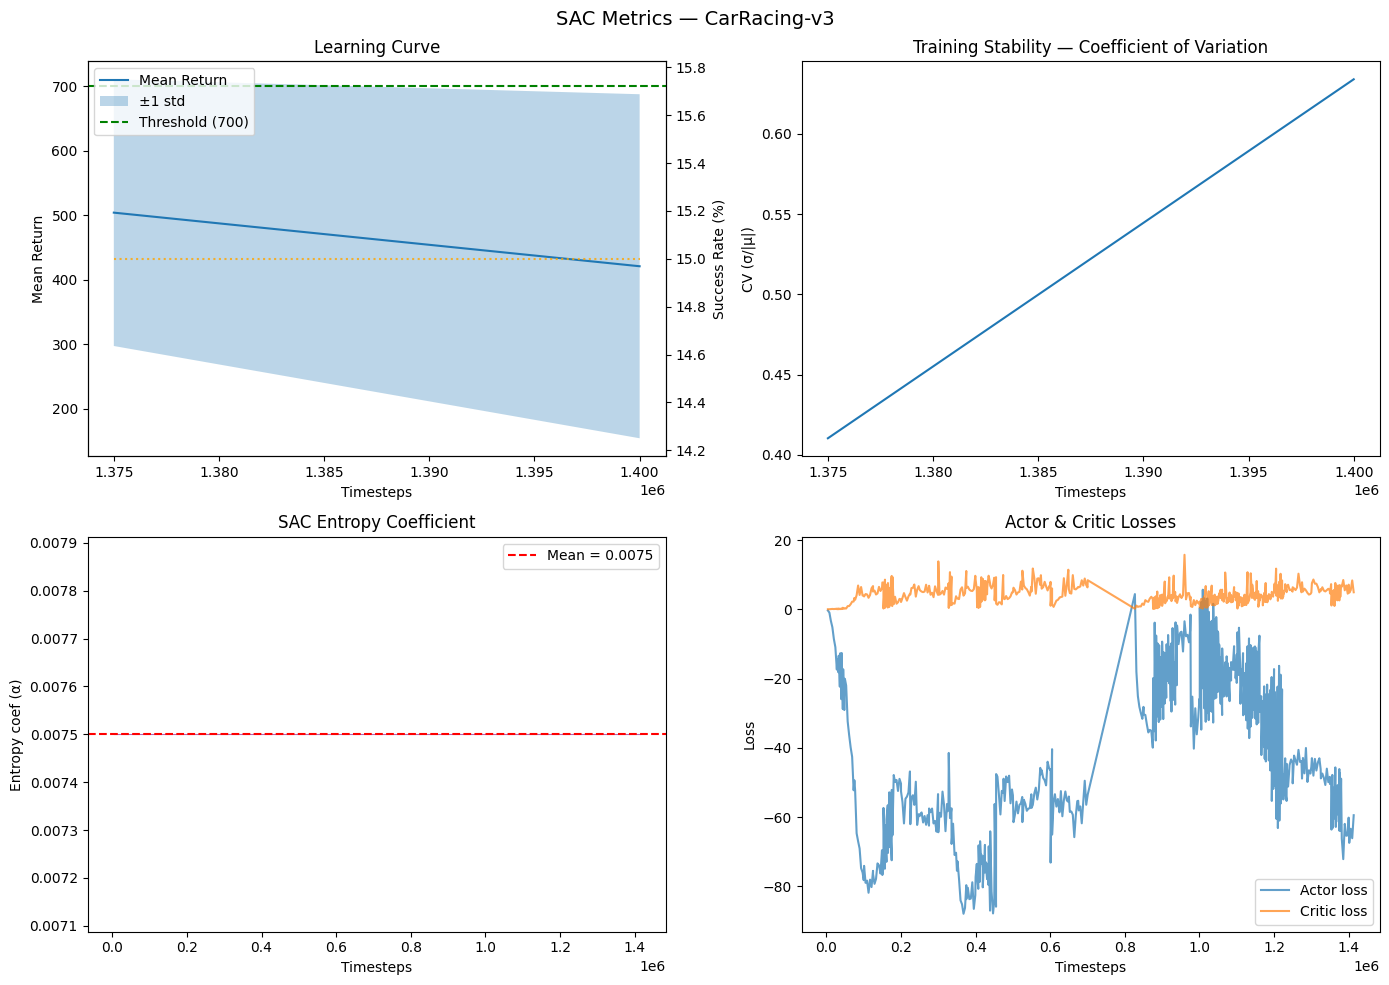

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"{rl_type} Metrics — {env_str}", fontsize=14)

# (a) Learning curve + success rate
ax = axes[0, 0]
ax.plot(timesteps, mean_results, label="Mean Return")
ax.fill_between(timesteps, mean_results - std_results, mean_results + std_results,
                alpha=0.3, label="±1 std")
ax.axhline(SOLVE_THRESHOLD, color='green', linestyle='--', label=f"Threshold ({SOLVE_THRESHOLD})")
ax.set_xlabel("Timesteps"); ax.set_ylabel("Mean Return")
ax.set_title("Learning Curve"); ax.legend(loc="upper left")
ax2 = ax.twinx()
ax2.plot(timesteps, success_rates * 100, color='orange', linestyle=':', alpha=0.8)
ax2.set_ylabel("Success Rate (%)")

# (b) Stability CV
ax = axes[0, 1]
ax.plot(timesteps, cv_series)
ax.set_xlabel("Timesteps"); ax.set_ylabel("CV (σ/|μ|)")
ax.set_title("Training Stability — Coefficient of Variation")

# (c) Clip fraction
ax = axes[1, 0]
if len(ent_vals) > 0:
    ax.plot(ent_steps, ent_vals, alpha=0.6, linewidth=0.8, color='purple')
    ax.axhline(mean_ent_coef, color='red', linestyle='--', label=f"Mean = {mean_ent_coef:.4f}")
    ax.set_xlabel("Timesteps"); ax.set_ylabel("Entropy coef (α)")
    ax.set_title("SAC Entropy Coefficient"); ax.legend()
else:
    ax.text(0.5, 0.5, "No entropy coefficient data found",
            ha='center', va='center', transform=ax.transAxes)
    ax.set_title("SAC Entropy Coefficient")

# (d) Policy & value losses
ax = axes[1, 1]
if len(actor_vals) > 0:
    ax.plot(actor_steps, actor_vals, label="Actor loss", alpha=0.7)
if len(critic_vals) > 0:
    ax.plot(critic_steps, critic_vals, label="Critic loss", alpha=0.7)
ax.set_xlabel("Timesteps"); ax.set_ylabel("Loss")
ax.set_title("Actor & Critic Losses"); ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(log_dir, f"{rl_type}_{env_str}_full_metrics.png"), dpi=150)
plt.show()